In [ ]:
1+1

# DFT Codebook PMI 与右半阵列 Muting 方向图验证

这个 notebook 验证 `dft.py`、`pmi.py` 和 `muting.py` 产生的波束。它不运行 Sionna RT，而是直接计算理想各向同性阵元、半波长间距 UPA 的阵列因子。

需要特别区分：

- **Array gain**：每个状态分别按其有源输入功率归一化。关闭右半阵列后，峰值通常下降约 3 dB。
- **Effective beam power / EIRP factor**：sleep 权重不重新归一化。除约 3 dB 阵列增益损失外，还包含约 3 dB 发射功率损失，峰值总损失通常约 6 dB。

方向图使用方向余弦坐标：水平轴 $u_h$，垂直轴 $u_v$；圆盘 $u_h^2+u_v^2\leq1$ 是可见空间。

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Find the package root whether the notebook is launched from the project root
# or directly from the notebook/ directory. Modules live under
# src/mMIMO_sleep/codebook/, so add src/mMIMO_sleep to sys.path.
search_roots = [Path.cwd(), *Path.cwd().parents]
MODULE_ROOT = next(
    (p for p in search_roots if (p / 'src' / 'mMIMO_sleep' / 'codebook' / 'dft.py').exists()),
    None,
)
if MODULE_ROOT is None:
    raise FileNotFoundError(
        'Cannot find src/mMIMO_sleep/codebook. Start Jupyter from the project directory '
        'or update MODULE_ROOT manually.'
    )
sys.path.insert(0, str(MODULE_ROOT / 'src' / 'mMIMO_sleep'))

from codebook.dft import generate_dft_codebook
from codebook.muting import (
    active_power_fraction,
    apply_muting_mask,
    create_right_half_mask,
)
from codebook.pmi import PMI, beam_index_to_pmi, pmi_to_beam_index

print('Module root:', MODULE_ROOT)
print('PyTorch:', torch.__version__)

Module root: /Users/alonekite/CascadeProjects/mMIMO_sleep
PyTorch: 2.2.2


## 1. 配置与基本检查

下面的默认配置对应 8×8 UPA、水平 32 个 DFT beam、垂直 8 个 DFT beam，共 256 个 PMI。阵元顺序与四个 `.py` 文件一致：水平索引变化最快。

In [2]:
NUM_VERTICAL = 8
NUM_HORIZONTAL = 8
NUM_VERTICAL_BEAMS = 8       # i12 = 0,...,7
NUM_HORIZONTAL_BEAMS = 32    # i11 = 0,...,31
SPACING_WAVELENGTHS = 0.5
PHASE_SIGN = 1
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

codebook = generate_dft_codebook(
    NUM_VERTICAL,
    NUM_HORIZONTAL,
    NUM_VERTICAL_BEAMS,
    NUM_HORIZONTAL_BEAMS,
    phase_sign=PHASE_SIGN,
    device=DEVICE,
)
right_half_mask = create_right_half_mask(
    NUM_VERTICAL, NUM_HORIZONTAL, device=DEVICE
)
sleep_codebook = apply_muting_mask(codebook, right_half_mask)

assert codebook.shape == (256, 64)
assert torch.allclose(
    codebook.abs().square().sum(-1),
    torch.ones(256, device=DEVICE),
    atol=1e-5,
)
assert abs(active_power_fraction(right_half_mask) - 0.5) < 1e-6
assert beam_index_to_pmi(
    pmi_to_beam_index(
        PMI(i11=17, i12=3),
        num_horizontal_beams=NUM_HORIZONTAL_BEAMS,
        num_vertical_beams=NUM_VERTICAL_BEAMS,
    ),
    num_horizontal_beams=NUM_HORIZONTAL_BEAMS,
    num_vertical_beams=NUM_VERTICAL_BEAMS,
) == PMI(i11=17, i12=3)

print('Device:', DEVICE)
print('Codebook shape:', tuple(codebook.shape))
print('Normal ||w||^2:', codebook[0].abs().square().sum().item())
print('Sleep  ||w||^2:', sleep_codebook[0].abs().square().sum().item())

Device: cpu
Codebook shape: (256, 64)
Normal ||w||^2: 0.9999999403953552
Sleep  ||w||^2: 0.4999999403953552


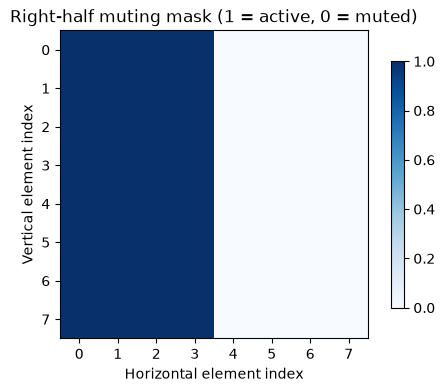

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
mask_2d = right_half_mask.reshape(NUM_VERTICAL, NUM_HORIZONTAL).cpu().numpy()
im = ax.imshow(mask_2d, vmin=0, vmax=1, cmap='Blues', origin='upper')
ax.set_title('Right-half muting mask (1 = active, 0 = muted)')
ax.set_xlabel('Horizontal element index')
ax.set_ylabel('Vertical element index')
ax.set_xticks(range(NUM_HORIZONTAL))
ax.set_yticks(range(NUM_VERTICAL))
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 2. 阵列因子计算函数

采用 UPA 位于垂直–水平平面、阵元间距为 $d/\lambda=0.5$ 的约定。若后续 Sionna 场景采用不同阵列轴或角度定义，需要修改坐标映射，但 codebook 与 mask 的内部一致性检查仍然有效。

In [4]:
EPS = 1e-12

def make_uv_grid(num_points: int = 241):
    u = torch.linspace(-1.0, 1.0, num_points, device=DEVICE)
    u_v, u_h = torch.meshgrid(u, u, indexing='ij')
    visible = u_h.square() + u_v.square() <= 1.0
    return u_h, u_v, visible


def array_factor_power(weights: torch.Tensor, u_h: torch.Tensor, u_v: torch.Tensor):
    """Unnormalized |AF|^2. It retains the sleep-state TX-power loss."""
    weights_2d = weights.reshape(NUM_VERTICAL, NUM_HORIZONTAL)
    real_dtype = weights.real.dtype
    n_v = torch.arange(NUM_VERTICAL, device=weights.device, dtype=real_dtype)
    n_h = torch.arange(NUM_HORIZONTAL, device=weights.device, dtype=real_dtype)
    phase_scale = -2.0 * torch.pi * SPACING_WAVELENGTHS
    steering_v = torch.exp(1j * phase_scale * u_v[..., None] * n_v)
    steering_h = torch.exp(1j * phase_scale * u_h[..., None] * n_h)
    field = torch.einsum('...v,vh,...h->...', steering_v, weights_2d, steering_h)
    return field.abs().square()


def to_db(power: torch.Tensor):
    return 10.0 * torch.log10(power.clamp_min(EPS))


def normalized_array_gain(power: torch.Tensor, weights: torch.Tensor):
    """Array gain normalized by total active input power of that state."""
    input_power = weights.abs().square().sum()
    return power / input_power


def masked_peak(power: torch.Tensor, visible: torch.Tensor, u_h: torch.Tensor, u_v: torch.Tensor):
    search = torch.where(visible, power, torch.tensor(-1.0, device=power.device))
    flat_index = int(search.argmax().item())
    row, col = np.unravel_index(flat_index, tuple(power.shape))
    peak_uh = float(u_h[row, col].item())
    peak_uv = float(u_v[row, col].item())
    elevation = np.degrees(np.arcsin(np.clip(peak_uv, -1.0, 1.0)))
    cos_el = max(np.cos(np.radians(elevation)), 1e-9)
    azimuth = np.degrees(np.arcsin(np.clip(peak_uh / cos_el, -1.0, 1.0)))
    return {
        'row': row, 'col': col, 'u_h': peak_uh, 'u_v': peak_uv,
        'azimuth_deg': float(azimuth), 'elevation_deg': float(elevation),
        'peak_power': float(power[row, col].item()),
    }


def angular_separation_deg(first: dict, second: dict):
    def unit_vector(item):
        uh, uv = item['u_h'], item['u_v']
        forward = np.sqrt(max(0.0, 1.0 - uh * uh - uv * uv))
        return np.array([forward, uh, uv])
    cosine = np.clip(np.dot(unit_vector(first), unit_vector(second)), -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))

## 3. 查看任意一个 PMI

两张二维图使用相同色标，显示的是按各状态输入功率归一化后的 array gain。下方切面同时显示：

- 实线：array gain；
- 虚线：不重归一化的 effective beam power，因此包含 sleep 状态的额外 3 dB TX-power loss。

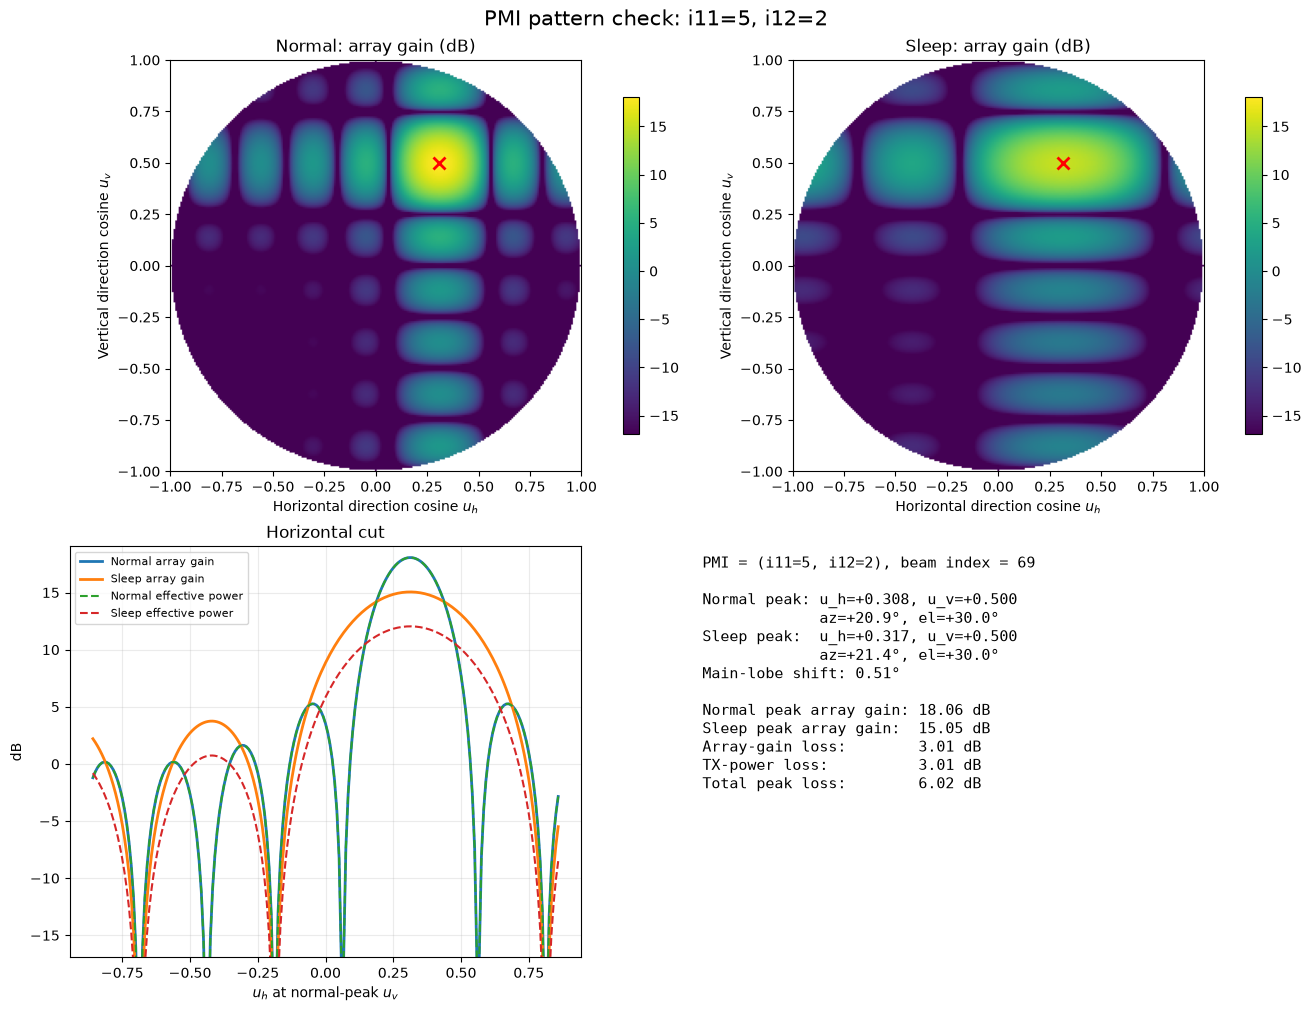

In [9]:
def evaluate_pmi(i11: int, i12: int, grid_points: int = 241):
    pmi = PMI(i11=i11, i12=i12)
    beam_index = pmi_to_beam_index(
        pmi,
        num_horizontal_beams=NUM_HORIZONTAL_BEAMS,
        num_vertical_beams=NUM_VERTICAL_BEAMS,
    )
    w_normal = codebook[beam_index]
    w_sleep = sleep_codebook[beam_index]
    u_h, u_v, visible = make_uv_grid(grid_points)

    raw_normal = array_factor_power(w_normal, u_h, u_v)
    raw_sleep = array_factor_power(w_sleep, u_h, u_v)
    gain_normal = normalized_array_gain(raw_normal, w_normal)
    gain_sleep = normalized_array_gain(raw_sleep, w_sleep)

    normal_peak = masked_peak(gain_normal, visible, u_h, u_v)
    sleep_peak = masked_peak(gain_sleep, visible, u_h, u_v)
    raw_normal_peak = masked_peak(raw_normal, visible, u_h, u_v)
    raw_sleep_peak = masked_peak(raw_sleep, visible, u_h, u_v)

    metrics = {
        'beam_index': beam_index,
        'normal_peak_gain_db': 10 * np.log10(normal_peak['peak_power']),
        'sleep_peak_gain_db': 10 * np.log10(sleep_peak['peak_power']),
        'array_gain_loss_db': 10 * np.log10(normal_peak['peak_power'] / sleep_peak['peak_power']),
        'tx_power_loss_db': 10 * np.log10(
            w_normal.abs().square().sum().item() / w_sleep.abs().square().sum().item()
        ),
        'total_peak_loss_db': 10 * np.log10(
            raw_normal_peak['peak_power'] / raw_sleep_peak['peak_power']
        ),
        'normal_peak': normal_peak,
        'sleep_peak': sleep_peak,
        'main_lobe_shift_deg': angular_separation_deg(normal_peak, sleep_peak),
    }
    data = {
        'u_h': u_h, 'u_v': u_v, 'visible': visible,
        'raw_normal': raw_normal, 'raw_sleep': raw_sleep,
        'gain_normal': gain_normal, 'gain_sleep': gain_sleep,
        'w_normal': w_normal, 'w_sleep': w_sleep,
    }
    return metrics, data


def plot_pmi(i11: int, i12: int, grid_points: int = 241):
    metrics, data = evaluate_pmi(i11, i12, grid_points)
    uh = data['u_h'].cpu().numpy()
    uv = data['u_v'].cpu().numpy()
    visible = data['visible'].cpu().numpy()
    gain_normal_db = to_db(data['gain_normal']).cpu().numpy()
    gain_sleep_db = to_db(data['gain_sleep']).cpu().numpy()
    raw_normal_db = to_db(data['raw_normal']).cpu().numpy()
    raw_sleep_db = to_db(data['raw_sleep']).cpu().numpy()

    vmax = np.nanmax(np.where(visible, gain_normal_db, np.nan))
    vmin = vmax - 35.0
    extent = [-1, 1, -1, 1]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    for ax, values, title in [
        (axes[0, 0], gain_normal_db, 'Normal: array gain (dB)'),
        (axes[0, 1], gain_sleep_db, 'Sleep: array gain (dB)'),
    ]:
        image = ax.imshow(
            np.where(visible, values, np.nan), origin='lower', extent=extent,
            vmin=vmin, vmax=vmax, cmap='viridis', aspect='equal',
        )
        ax.set_title(title)
        ax.set_xlabel(r'Horizontal direction cosine $u_h$')
        ax.set_ylabel(r'Vertical direction cosine $u_v$')
        fig.colorbar(image, ax=ax, shrink=0.82)

    axes[0, 0].plot(metrics['normal_peak']['u_h'], metrics['normal_peak']['u_v'], 'rx', ms=9, mew=2)
    axes[0, 1].plot(metrics['sleep_peak']['u_h'], metrics['sleep_peak']['u_v'], 'rx', ms=9, mew=2)

    row = metrics['normal_peak']['row']
    u_axis = uh[row, :]
    valid_cut = visible[row, :]
    ax = axes[1, 0]
    ax.plot(u_axis[valid_cut], gain_normal_db[row, valid_cut], label='Normal array gain', lw=2)
    ax.plot(u_axis[valid_cut], gain_sleep_db[row, valid_cut], label='Sleep array gain', lw=2)
    ax.plot(u_axis[valid_cut], raw_normal_db[row, valid_cut], '--', label='Normal effective power')
    ax.plot(u_axis[valid_cut], raw_sleep_db[row, valid_cut], '--', label='Sleep effective power')
    ax.set_ylim(vmin, vmax + 1)
    ax.set_xlabel(r'$u_h$ at normal-peak $u_v$')
    ax.set_ylabel('dB')
    ax.set_title('Horizontal cut')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    ax.axis('off')
    normal = metrics['normal_peak']
    sleep = metrics['sleep_peak']
    lines = [
        f"PMI = (i11={i11}, i12={i12}), beam index = {metrics['beam_index']}",
        '',
        f"Normal peak: u_h={normal['u_h']:+.3f}, u_v={normal['u_v']:+.3f}",
        f"             az={normal['azimuth_deg']:+.1f}°, el={normal['elevation_deg']:+.1f}°",
        f"Sleep peak:  u_h={sleep['u_h']:+.3f}, u_v={sleep['u_v']:+.3f}",
        f"             az={sleep['azimuth_deg']:+.1f}°, el={sleep['elevation_deg']:+.1f}°",
        f"Main-lobe shift: {metrics['main_lobe_shift_deg']:.2f}°",
        '',
        f"Normal peak array gain: {metrics['normal_peak_gain_db']:.2f} dB",
        f"Sleep peak array gain:  {metrics['sleep_peak_gain_db']:.2f} dB",
        f"Array-gain loss:        {metrics['array_gain_loss_db']:.2f} dB",
        f"TX-power loss:          {metrics['tx_power_loss_db']:.2f} dB",
        f"Total peak loss:        {metrics['total_peak_loss_db']:.2f} dB",
    ]
    ax.text(0.02, 0.98, '\n'.join(lines), va='top', family='monospace', fontsize=11)
    fig.suptitle(f'PMI pattern check: i11={i11}, i12={i12}', fontsize=15)
    return fig, metrics


fig, metrics = plot_pmi(i11=5, i12=2)
plt.show()

### 选择其他 PMI

修改 `PMI_I11` 和 `PMI_I12` 后重新运行本 cell。它正好体现 `PMI -> beam_index -> w_normal -> mask*w_normal` 的项目数据流。

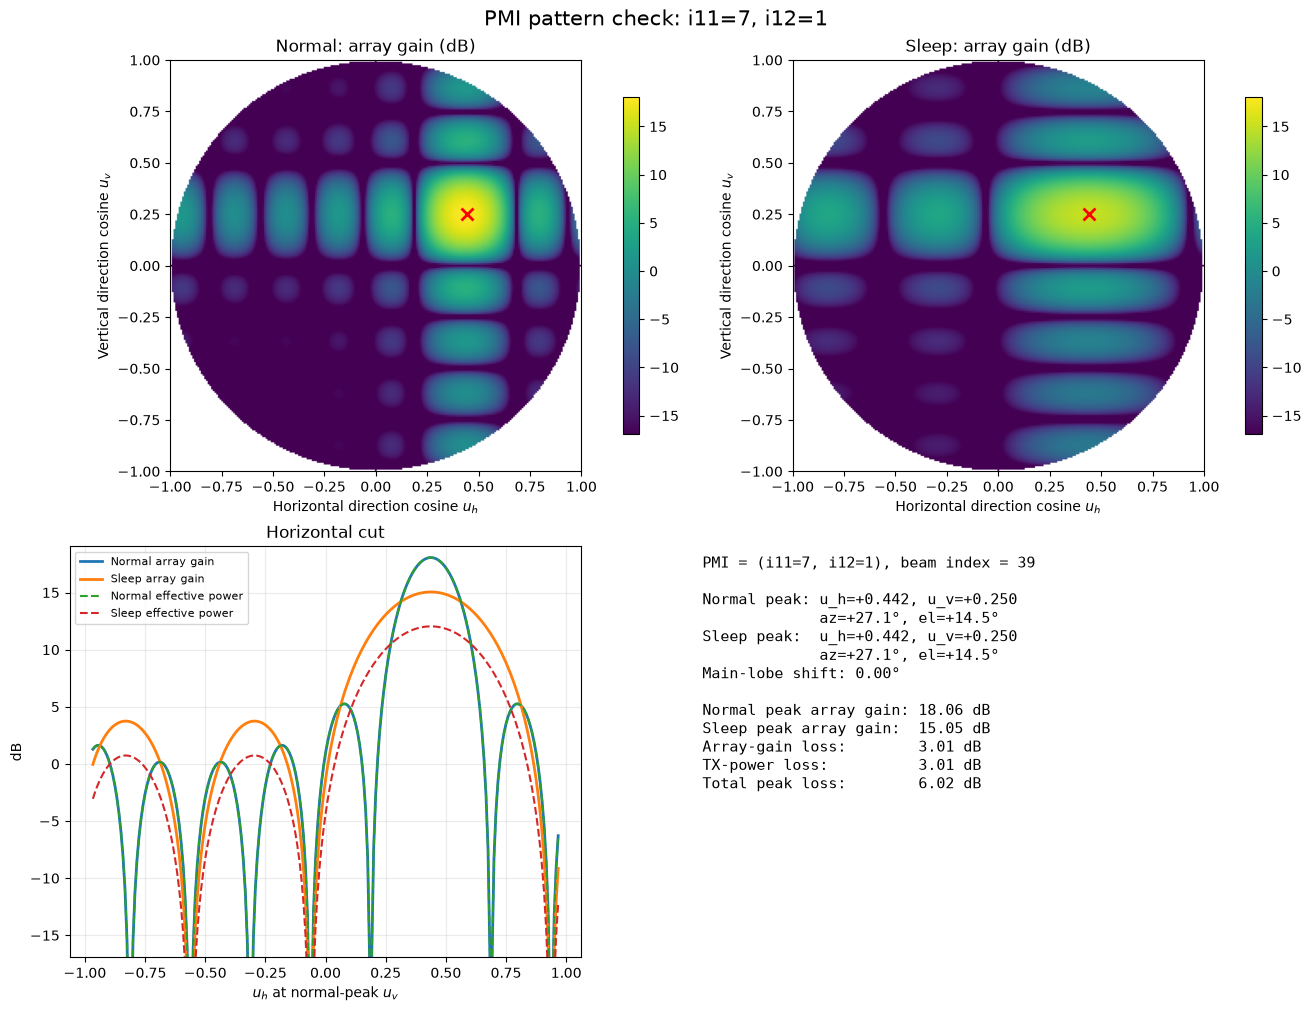

In [10]:
PMI_I11 = 7   # 0,...,31
PMI_I12 = 1   # 0,...,7

fig, metrics = plot_pmi(PMI_I11, PMI_I12)
plt.show()

## 4. 遍历全部 256 个 PMI

这里不把 512 张二维图同时铺在 notebook 中，而是把每个 PMI 的关键检查量汇总成 8×32 热力图：array-gain loss、总峰值损失和主瓣偏移。边缘/不可见方向的 DFT codeword 可能在可见圆盘边界处截断，因此其结果不一定恰好是 3/6 dB。

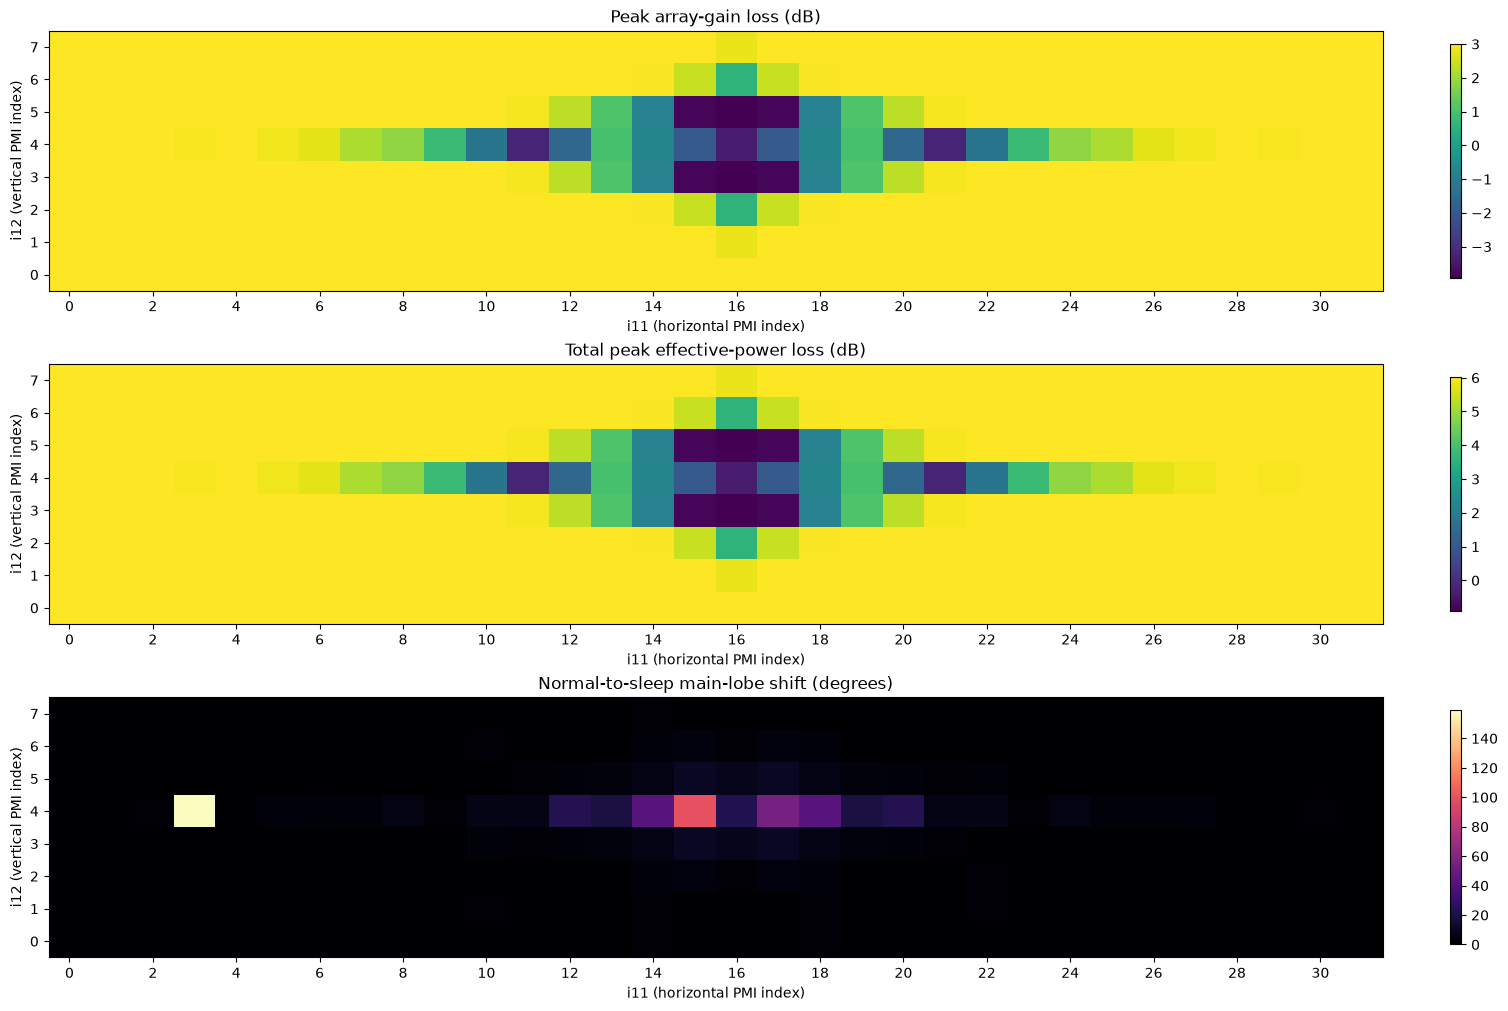

Array-gain loss: min=-3.92, median=3.01, max=3.01 dB
Total peak loss: min=-0.91, median=6.02, max=6.02 dB
Main-lobe shift: min=0.00, median=0.00, max=159.05 deg


In [11]:
def analyze_all_pmis(grid_points: int = 121):
    array_loss = np.empty((NUM_VERTICAL_BEAMS, NUM_HORIZONTAL_BEAMS))
    total_loss = np.empty_like(array_loss)
    lobe_shift = np.empty_like(array_loss)
    for i12 in range(NUM_VERTICAL_BEAMS):
        for i11 in range(NUM_HORIZONTAL_BEAMS):
            result, _ = evaluate_pmi(i11, i12, grid_points=grid_points)
            array_loss[i12, i11] = result['array_gain_loss_db']
            total_loss[i12, i11] = result['total_peak_loss_db']
            lobe_shift[i12, i11] = result['main_lobe_shift_deg']
    return array_loss, total_loss, lobe_shift


array_loss, total_loss, lobe_shift = analyze_all_pmis(grid_points=121)
fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
for ax, values, title, cmap in [
    (axes[0], array_loss, 'Peak array-gain loss (dB)', 'viridis'),
    (axes[1], total_loss, 'Total peak effective-power loss (dB)', 'viridis'),
    (axes[2], lobe_shift, 'Normal-to-sleep main-lobe shift (degrees)', 'magma'),
]:
    image = ax.imshow(values, origin='lower', aspect='auto', cmap=cmap)
    ax.set_xlabel('i11 (horizontal PMI index)')
    ax.set_ylabel('i12 (vertical PMI index)')
    ax.set_title(title)
    ax.set_xticks(range(0, NUM_HORIZONTAL_BEAMS, 2))
    ax.set_yticks(range(NUM_VERTICAL_BEAMS))
    fig.colorbar(image, ax=ax, shrink=0.9)
plt.show()

print(f'Array-gain loss: min={array_loss.min():.2f}, median={np.median(array_loss):.2f}, max={array_loss.max():.2f} dB')
print(f'Total peak loss: min={total_loss.min():.2f}, median={np.median(total_loss):.2f}, max={total_loss.max():.2f} dB')
print(f'Main-lobe shift: min={lobe_shift.min():.2f}, median={np.median(lobe_shift):.2f}, max={lobe_shift.max():.2f} deg')

In [ ]:
# Total peak effective-power loss (dB)
# i11 as horizontal axis, i12 as vertical axis.
fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(
    total_loss,
    origin='lower',
    aspect='auto',
    cmap='viridis',
)
ax.set_xlabel('i11 (horizontal PMI index)')
ax.set_ylabel('i12 (vertical PMI index)')
ax.set_title('Total peak effective-power loss (dB)')
ax.set_xticks(range(0, NUM_HORIZONTAL_BEAMS, 2))
ax.set_yticks(range(NUM_VERTICAL_BEAMS))
fig.colorbar(image, ax=ax, shrink=0.9)
plt.show()

print(f'Total peak loss: min={total_loss.min():.2f}, median={np.median(total_loss):.2f}, max={total_loss.max():.2f} dB')

## 5. 可选：把每个 PMI 导出成 PNG

下面默认不执行。需要完整人工检查时，将 `RUN_EXPORT` 改成 `True`。它会生成 256 张图，而不是让 notebook 页面承载所有输出。

In [12]:
def export_all_pmi_figures(output_dir: str | Path, grid_points: int = 161):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    for i12 in range(NUM_VERTICAL_BEAMS):
        for i11 in range(NUM_HORIZONTAL_BEAMS):
            fig, _ = plot_pmi(i11, i12, grid_points=grid_points)
            filename = output_dir / f'pmi_i11_{i11:02d}_i12_{i12:02d}.png'
            fig.savefig(filename, dpi=130, bbox_inches='tight')
            plt.close(fig)
    print(f'Exported {NUM_HORIZONTAL_BEAMS * NUM_VERTICAL_BEAMS} figures to {output_dir.resolve()}')


RUN_EXPORT = True
if RUN_EXPORT:
    export_all_pmi_figures(MODULE_ROOT / 'outputs' / 'pmi_patterns')

Exported 256 figures to /Users/alonekite/CascadeProjects/mMIMO_sleep/outputs/pmi_patterns


## 6. 结果判读与项目边界

对可见空间内、没有被边界截断的普通 beam，预期观察到：

1. Normal 与 right-half muted pattern 的主瓣方向大致一致；
2. Muting 后水平波束变宽，旁瓣结构改变；
3. 按各状态输入功率归一化，峰值 array gain 约下降 3 dB；
4. sleep 权重不重归一化时，另有约 3 dB TX-power loss，总峰值 effective-power loss 约 6 dB。

这只是理想阵列因子验证，不包含真实单元方向图、双极化、互耦、安装平台或 Sionna RT 场景传播。项目后续计算每个 UE 的 ground-truth sleep MCS 时，仍应使用同一传播信道矩阵 $H$，分别计算 $H w_{normal}$ 与 $H(Mw_{normal})$。